<a href="https://colab.research.google.com/github/kalaiarasan2448/Apex_Automation/blob/main/Stock_Price_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv("/content/symbols_valid_meta.csv")
data.head()

,Nasdaq Traded,Symbol,Security Name,Listing Exchange,Market Category,ETF,Round Lot Size,Test Issue,Financial Status,CQS Symbol,NASDAQ Symbol,NextShares
0,Y,A,"Agilent Technologies, Inc. Common Stock",N,,N,100.0,N,NaN,A,A,N
1,Y,AA,Alcoa Corporation Common Stock,N,,N,100.0,N,NaN,AA,AA,N
2,Y,AAAU,Perth Mint Physical Gold ETF,P,,Y,100.0,N,NaN,AAAU,AAAU,N
3,Y,AACG,ATA Creativity Global - American Depositary Sh...,Q,G,N,100.0,N,N,NaN,AACG,N
4,Y,AADR,AdvisorShares Dorsey Wright ADR ETF,P,,Y,100.0,N,NaN,AADR,AADR,N


In [4]:
data = pd.read_csv('/content/EW-MAX.csv')
data.head()

,Date,Open,High,Low,Close,Adj_Close,Volume
0,2000/3/27,3.812500,4.156250,3.812500,4.125000,4.125000,3675600
1,2000/3/28,4.125000,4.125000,4.000000,4.015625,4.015625,1077600
2,2000/3/29,4.000000,4.031250,3.953125,4.000000,4.000000,437200
3,2000/3/30,4.000000,4.000000,3.843750,3.843750,3.843750,1883600
4,2000/3/31,3.734375,3.734375,3.390625,3.390625,3.390625,7931600


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print("Model predictions:", predictions[:5])
print("Actual values:", y_test[:5])

Model predictions: [102.98638889   6.29307449  50.42089692  45.30730608  43.48780819]
Actual values: [104.         6.37      50.720001  45.244999  43.220001]


In [5]:
data['Prediction'] = data['Close'].shift(-1)

X = np.array(data[['Close']])
X = X[:-1]

y = np.array(data['Prediction'])
y = y[:-1]

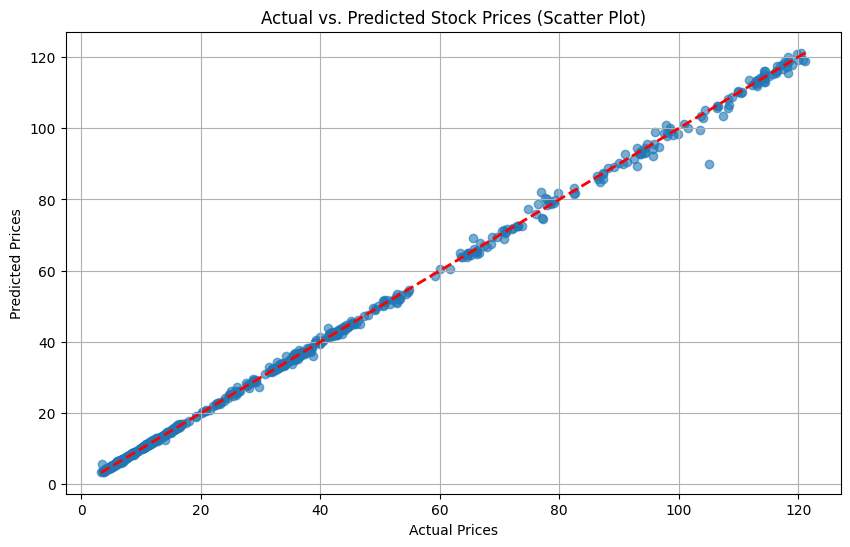

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Stock Prices (Scatter Plot)')
plt.grid(True)
plt.show()

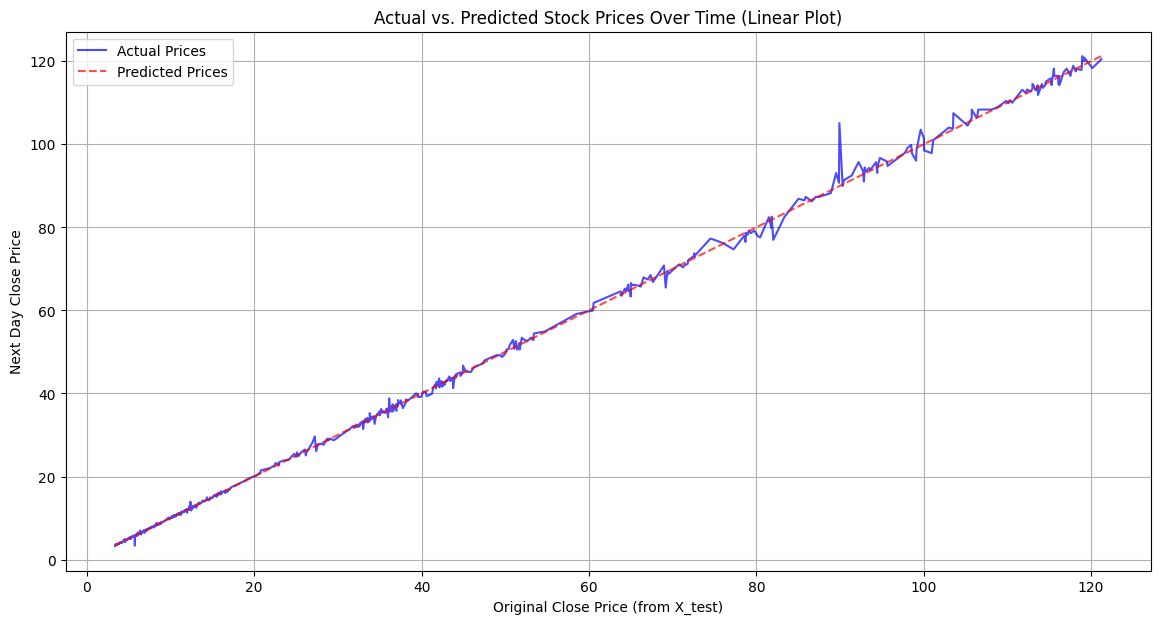

In [8]:
plt.figure(figsize=(14, 7))
# Sort the test data by the 'Close' values for a more continuous line plot
sort_indices = np.argsort(X_test.flatten())
plt.plot(X_test[sort_indices], y_test[sort_indices], label='Actual Prices', color='blue', alpha=0.7)
plt.plot(X_test[sort_indices], predictions[sort_indices], label='Predicted Prices', color='red', linestyle='--', alpha=0.7)
plt.xlabel('Original Close Price (from X_test)')
plt.ylabel('Next Day Close Price')
plt.title('Actual vs. Predicted Stock Prices Over Time (Linear Plot)')
plt.legend()
plt.grid(True)
plt.show()